In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, optimize

https://stackoverflow.com/questions/79878768/fitting-model-to-data-using-curve-fit-in-python

In [2]:
y = np.array([16000., 15000., 15000., 14000., 14000., 13000., 14000., 14000., 14000., 14000., 14000., 14000., 14000., 14000., 14000.])
t = np.array([0. , 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14.])

In [3]:
def model(t, y, Lambda, beta, mu, gamma, tau, w, alpha, Gamma, pi):
    S, E, I, T, R = y
    dSdt = Lambda - beta * I * S - mu * S
    dEdt = beta * I * S - (gamma + tau + mu) * E
    dIdt = gamma * E + w * R - (alpha + Gamma + mu) * I
    dTdt = alpha * I + tau * E - (mu + pi) * T
    dRdt = pi * T  -(w + mu) * R
    return np.array([dSdt, dEdt, dIdt, dTdt, dRdt])

In [32]:
y0 = [4e4, 1.6e4, 1e2, 2e2, 3e2]

In [33]:
p0 = [55730., 0.00062, 0.0174, 0.5, 0.37, 0.7, 0.37, 0.00068, 0.8]

In [34]:
def solver(t, Lambda, beta, mu, gamma, tau, w, alpha, Gamma, pi, *y0):
    solution = integrate.solve_ivp(model, [t[0], t[-1]], y0=y0, t_eval=t, method="LSODA", args=(Lambda, beta, mu, gamma, tau, w, alpha, Gamma, pi))
    return solution.y[1, :]

In [35]:
popt, pcov = optimize.curve_fit(solver, t, y, p0=p0 + y0, bounds=[[0.] * 14, [np.inf] * 14])
popt

array([5.57222940e+04, 2.08094490e-03, 5.71557849e-01, 5.23662555e-01,
       2.43401953e+00, 7.31687795e-01, 1.23004211e+01, 4.50805351e-01,
       8.30132488e-01, 4.09633129e+04, 1.59970145e+04, 4.11560984e+02,
       8.07690427e+02, 2.10232998e+02])

In [36]:
tlin = np.linspace(t[0], t[-1], 200)

In [37]:
yhat = solver(tlin, *popt)

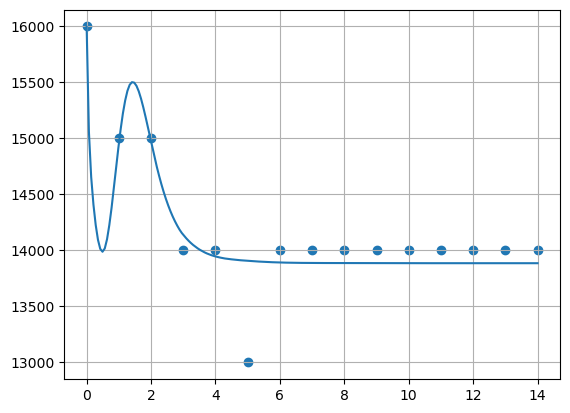

In [38]:
fig, axe = plt.subplots()
axe.scatter(t, y)
axe.plot(tlin, yhat)
axe.grid()